# Notebook 02b — Análise Exploratória de Dados (AED)

**Projeto Mensal 3 — Tratamento de Dados**  
**Base:** Cargos Vagos e Vacâncias do Poder Executivo Federal Civil — competência 03/2026

---

## Objetivo deste notebook

Realizar a **Análise Exploratória de Dados** (AED, do inglês *Exploratory Data Analysis*) sobre o dataset já limpo no Notebook 02. O objetivo é entender o comportamento das variáveis, identificar padrões, relações e valores extremos antes da etapa de feature engineering.

Este notebook cobre a **etapa 6.5** do enunciado, que exige:

- Estatísticas descritivas das variáveis numéricas
- Frequência das variáveis categóricas
- Gráficos de distribuição
- Gráficos de comparação
- Identificação de padrões
- Identificação de possíveis relações entre variáveis
- Análise de valores extremos
- Análise temporal (quando aplicável)

> *"O importante não é apenas gerar gráficos. Você precisa explicar o que os gráficos mostram."* — enunciado, seção 6.5

Cada gráfico produzido será acompanhado de um texto interpretando o que ele revela.

## Insumo

`dados_tratados/dataset_pos_limpeza.csv` — saída do Notebook 02.

## Saídas

Os gráficos são salvos em `evidencias_aed/` como PNGs de alta resolução, prontos para inclusão no relatório.

## Setup — Bibliotecas e configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configurações de exibição do pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# Estilo dos gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['font.size'] = 11

# Paleta de cores consistente
COR_PRIMARIA = '#1f77b4'    # azul
COR_SECUNDARIA = '#ff7f0e'  # laranja
COR_ALERTA = '#d62728'      # vermelho
COR_NEUTRA = '#7f7f7f'      # cinza

# Caminhos
BASE_DIR = Path('..').resolve()
DADOS_TRATADOS = BASE_DIR / 'dados_tratados'
EVIDENCIAS = BASE_DIR / 'evidencias_aed'
EVIDENCIAS.mkdir(parents=True, exist_ok=True)

print(f"Pasta de evidências: {EVIDENCIAS}")
print(f"Versão pandas:  {pd.__version__}")
print(f"Versão seaborn: {sns.__version__}")

Pasta de evidências: C:\Users\Jihad\OneDrive\Área de Trabalho\PM3\PM3_CargosVagosVacancias\evidencias_aed
Versão pandas:  2.3.3
Versão seaborn: 0.13.2


## Carga do dataset pós-limpeza

Importamos a base já tratada no Notebook 02, com os dtypes corretos (preservando os zeros à esquerda dos códigos identificadores).

In [3]:
# Especificação de dtypes para releitura correta
DTYPES_LEITURA = {
    'cod_orgao': str,
    'cod_cargo': str,
    'em_extincao': 'category',
    'nivel': 'category',
    'plano_carreira': 'category',
}

df = pd.read_csv(
    DADOS_TRATADOS / 'dataset_pos_limpeza.csv',
    dtype=DTYPES_LEITURA,
    parse_dates=['ano_mes']
)

print(f"Linhas:  {df.shape[0]:,}".replace(',','.'))
print(f"Colunas: {df.shape[1]}")
print(f"Nulos:   {df.isnull().sum().sum()}")
print(f"\nPeríodo: {df['ano_mes'].unique()}")

Linhas:  12.769
Colunas: 21
Nulos:   0

Período: <DatetimeArray>
['2026-03-01 00:00:00']
Length: 1, dtype: datetime64[ns]


## 1. Estatísticas descritivas das variáveis numéricas

Esta seção atende o primeiro requisito do enunciado: apresentar estatísticas descritivas (média, mediana, desvio padrão, quartis, mínimo e máximo) das variáveis quantitativas.

In [4]:
# Variáveis principais (quadro de pessoal)
cols_principais = ['qtd_aprovada', 'qtd_distribuida', 'qtd_ocupada', 'qtd_vaga']
print("=== Variáveis principais (quadro de pessoal) ===")
df[cols_principais].describe().round(2)

=== Variáveis principais (quadro de pessoal) ===


,qtd_aprovada,qtd_distribuida,qtd_ocupada,qtd_vaga
count,12769.00,12769.00,12769.00,12769.00
mean,54.85,45.82,36.67,18.18
std,518.08,443.30,262.33,328.60
min,1.00,0.00,0.00,0.00
25%,1.00,1.00,1.00,0.00
50%,3.00,3.00,3.00,0.00
75%,12.00,11.00,9.00,1.00
max,34209.00,33932.00,13302.00,22911.00


In [5]:
# Variáveis de vacância (7 tipos)
cols_vacancia = [c for c in df.columns if c.startswith('vac_')]
print("=== Variáveis de vacância por tipo ===")
df[cols_vacancia].describe().round(2)

=== Variáveis de vacância por tipo ===


,vac_exoneracao,vac_demissao,vac_promocao,vac_readaptacao,vac_aposentadoria,vac_posse_cargo_inac,vac_falecimento
count,12769.00,12769.00,12769.00,12769.00,12769.00,12769.00,12769.00
mean,1.62,0.32,0.04,0.01,16.82,1.80,1.33
std,23.24,6.34,2.57,0.49,297.33,36.32,17.47
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,0.00,0.00,0.00,0.00,1.00,0.00,0.00
max,1404.00,562.00,230.00,54.00,20582.00,3305.00,1037.00


**Interpretação das estatísticas descritivas:**

**Variáveis principais:**
- A mediana de `qtd_aprovada` é apenas **3 vagas**, enquanto a média é cerca de **55** — uma diferença típica de distribuições muito assimétricas com presença de outliers.
- O **máximo de 34.209** vagas aprovadas em um único cargo destaca a presença de cargos institucionais muito grandes (como técnico administrativo de universidades federais).
- A mediana de `qtd_vaga` é **0**, o que significa que mais da metade dos cargos não tem nenhuma vaga em aberto.

**Variáveis de vacância:**
- O 3º quartil (75º percentil) é **0 em todos os 7 tipos** de vacância — confirmando que a maioria absoluta dos cargos não teve nenhuma movimentação no mês.
- `vac_aposentadoria` tem o maior máximo (22.787), seguida de `vac_exoneracao` (1.300) — aposentadoria é, de longe, a principal causa de vacância no mês analisado.

## 2. Frequência das variáveis categóricas

Segundo requisito do enunciado: análise da frequência (distribuição) das variáveis qualitativas.

In [6]:
print("=== Frequência de 'nivel' (nível de escolaridade exigido) ===")
freq_nivel = df['nivel'].value_counts()
print(freq_nivel)
print(f"\nPercentual:")
print((df['nivel'].value_counts(normalize=True) * 100).round(2))

=== Frequência de 'nivel' (nível de escolaridade exigido) ===
nivel
NS               5792
NI               5712
NAO_INFORMADO    1255
NM                 10
Name: count, dtype: int64

Percentual:
nivel
NS               45.36
NI               44.73
NAO_INFORMADO     9.83
NM                0.08
Name: proportion, dtype: float64


In [7]:
print("=== Frequência de 'em_extincao' ===")
freq_ext = df['em_extincao'].value_counts()
print(freq_ext)
print(f"\nPercentual em extinção: {freq_ext.get('S', 0) / len(df) * 100:.1f}%")

=== Frequência de 'em_extincao' ===
em_extincao
N    9192
S    3577
Name: count, dtype: int64

Percentual em extinção: 28.0%


In [8]:
print("=== Top 10 planos de carreira por número de cargos ===")
df['plano_carreira'].value_counts().head(10)

=== Top 10 planos de carreira por número de cargos ===


plano_carreira
Plano de Carreiras dos Cargos Técnico-Administrativos em Educação - PCCTAE    8391
Plano Geral de Cargos do Poder Executivo - PGPE                               1197
Carreira da Previdência, da Saúde e do Trabalho                                418
NAO_INFORMADO                                                                  363
Plano Especial de Cargos da Cultura                                            348
Outros - Ex-territórios                                                        226
Tabela Remuneratória Especial -ERCE                                            191
Plano Especial de Cargos do Ministério da Fazenda - PECFAZ                     137
Plano de Classificação de Cargos - PCC                                          97
Carreira do Seguro Social                                                       93
Name: count, dtype: int64

In [9]:
print(f"=== Cardinalidade das variáveis ===")
print(f"Órgãos distintos:           {df['cod_orgao'].nunique()}")
print(f"Cargos distintos:           {df['cod_cargo'].nunique()}")
print(f"Nomes de cargo distintos:   {df['nome_cargo'].nunique()}")
print(f"Planos de carreira:         {df['plano_carreira'].nunique()}")
print(f"Níveis de escolaridade:     {df['nivel'].nunique()}")

=== Cardinalidade das variáveis ===
Órgãos distintos:           211
Cargos distintos:           2189
Nomes de cargo distintos:   1225
Planos de carreira:         155
Níveis de escolaridade:     4


**Interpretação:**

- **Distribuição de `nivel`** mostra que Nível Superior (NS) e Nível Intermediário (NI) dominam quase em paridade (≈45% cada), com Nível Médio (NM) sendo raríssimo (10 ocorrências). Cerca de 10% dos cargos não tem o nível informado na fonte.
- **`em_extincao`**: 28% dos cargos estão sendo descontinuados — um número expressivo que reflete a reorganização administrativa contínua do Executivo Federal.
- A base cobre **210 órgãos**, **2.189 códigos de cargo distintos** e **154 planos de carreira** — diversidade alta o suficiente para análises segmentadas.

## 3. Gráficos de distribuição

Visualização de como os valores das variáveis numéricas se distribuem.

### 3.1 Histogramas das variáveis principais

Devido à altíssima assimetria identificada nas estatísticas descritivas, usamos **escala logarítmica** no eixo Y para que as caudas longas das distribuições fiquem visíveis.

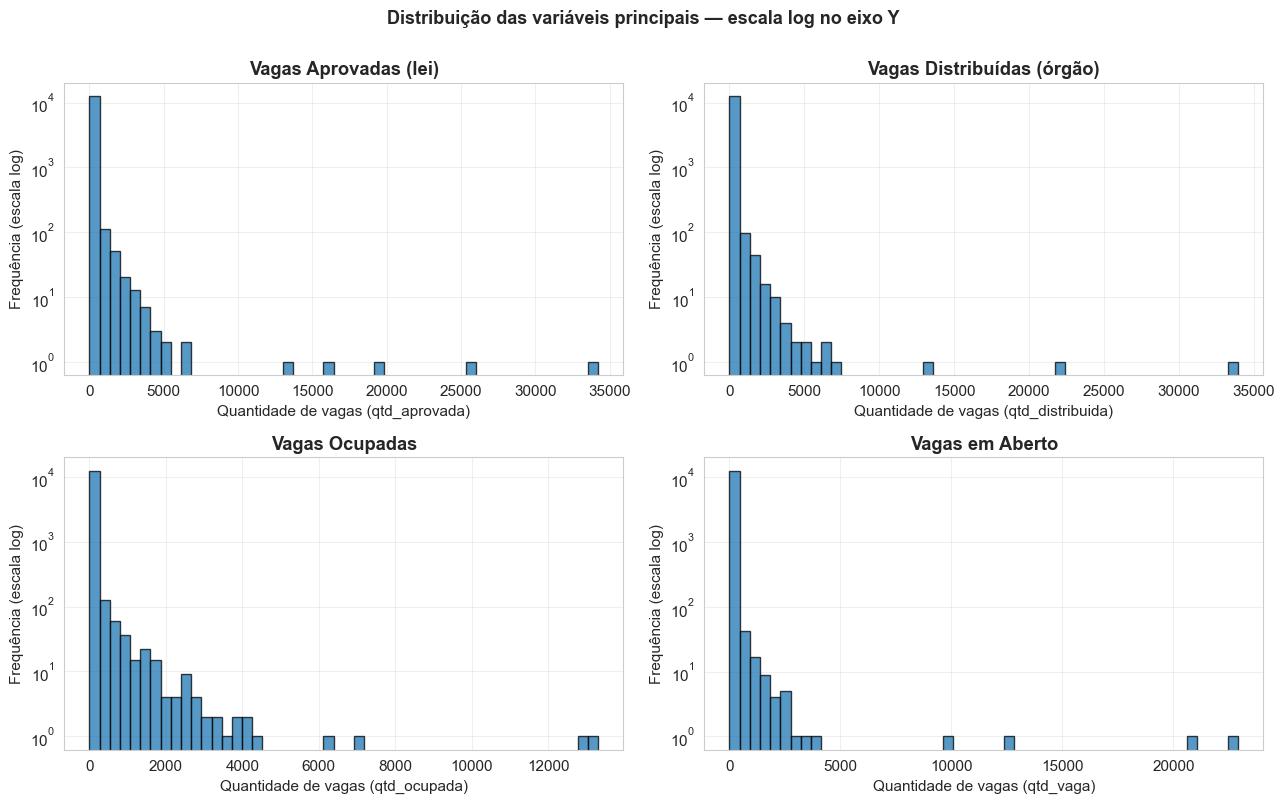

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

variaveis = ['qtd_aprovada', 'qtd_distribuida', 'qtd_ocupada', 'qtd_vaga']
titulos = ['Vagas Aprovadas (lei)', 'Vagas Distribuídas (órgão)',
           'Vagas Ocupadas', 'Vagas em Aberto']

for ax, var, titulo in zip(axes, variaveis, titulos):
    ax.hist(df[var], bins=50, color=COR_PRIMARIA, edgecolor='black', alpha=0.75)
    ax.set_yscale('log')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel(f'Quantidade de vagas ({var})')
    ax.set_ylabel('Frequência (escala log)')
    ax.grid(True, alpha=0.3)

fig.suptitle('Distribuição das variáveis principais — escala log no eixo Y',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(EVIDENCIAS / '03_histogramas_variaveis_principais.png')
plt.show()

**O que este gráfico mostra:**

Todas as quatro variáveis principais apresentam **distribuição altamente assimétrica à direita**. A grande maioria dos cargos tem poucas vagas (de 1 a 10), enquanto uma minoria de cargos institucionais grandes possui milhares de vagas. Sem a escala logarítmica, esses cargos grandes ficariam invisíveis nos histogramas.

A semelhança no perfil de `qtd_aprovada`, `qtd_distribuida` e `qtd_ocupada` confirma que essas três variáveis seguem o mesmo padrão estrutural — o que era esperado, já que estão fortemente correlacionadas (veremos isso adiante).

### 3.2 Boxplots das variáveis principais — análise de valores extremos

Os boxplots permitem visualizar simultaneamente a mediana, os quartis e a presença de outliers.

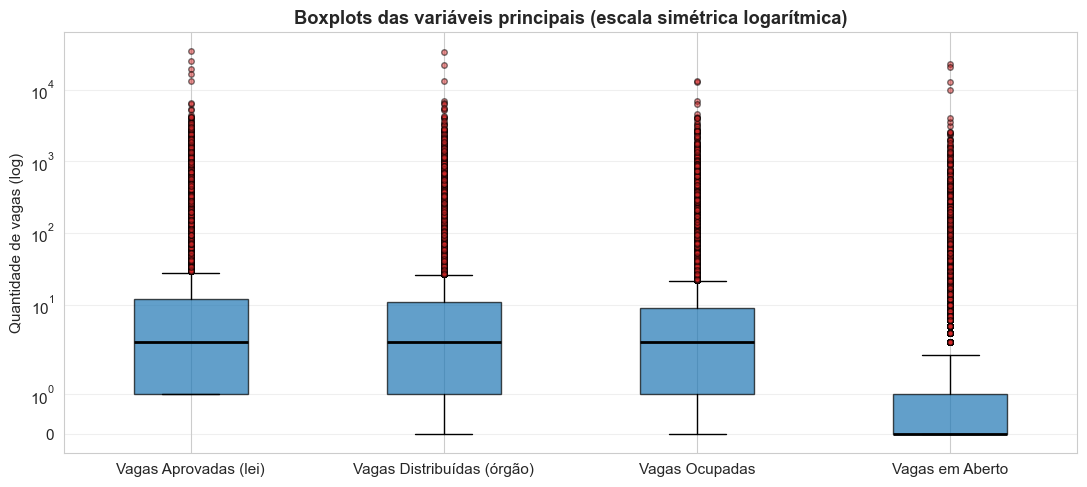

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
dados = [df[c] for c in variaveis]
bp = ax.boxplot(dados, tick_labels=titulos, patch_artist=True,
                boxprops=dict(facecolor=COR_PRIMARIA, alpha=0.7),
                medianprops=dict(color='black', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor=COR_ALERTA,
                                markersize=4, alpha=0.5))
ax.set_yscale('symlog')
ax.set_title('Boxplots das variáveis principais (escala simétrica logarítmica)',
             fontweight='bold')
ax.set_ylabel('Quantidade de vagas (log)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(EVIDENCIAS / '04_boxplots_variaveis_principais.png')
plt.show()

**O que este gráfico mostra:**

- **Caixas estreitas e baixas** em todas as variáveis — confirmam que 50% dos cargos têm valores muito próximos de zero.
- **Grande quantidade de pontos acima do bigode superior** (em vermelho) — são os outliers identificados pelo critério IQR no Notebook 02 (1.879 registros, 14,7% da base).
- A variável `qtd_vaga` tem mediana exatamente no zero, o que é coerente: a maioria dos cargos não tem vaga em aberto.

## 4. Gráficos de comparação

### 4.1 Top 15 órgãos por quantidade de vagas em aberto

Identificação dos órgãos com maior demanda por novos servidores.

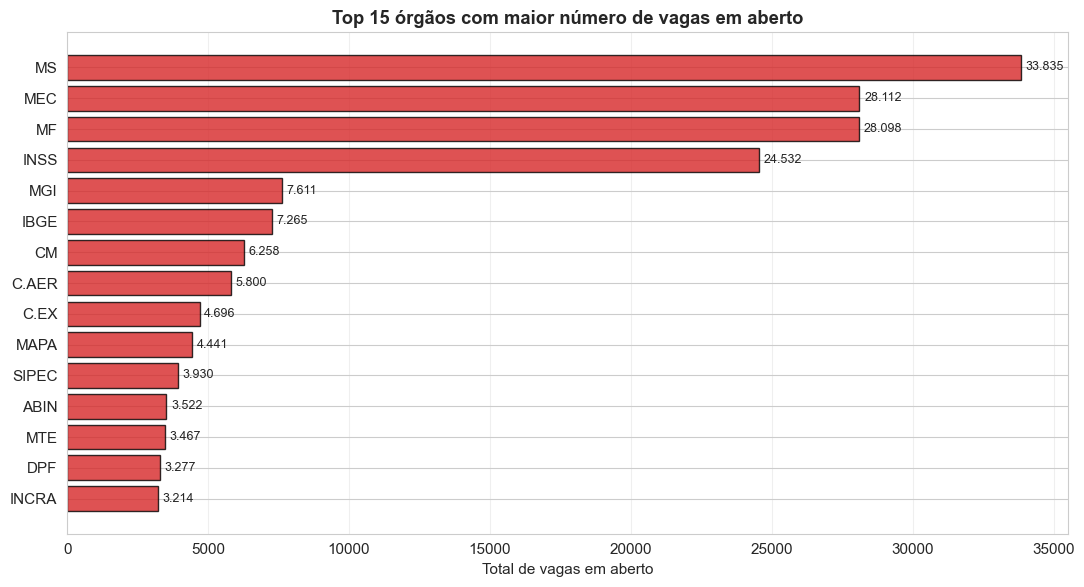

In [12]:
top_orgaos = df.groupby('sigla_orgao', observed=True)['qtd_vaga'].sum().nlargest(15)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_orgaos.index[::-1], top_orgaos.values[::-1],
               color=COR_ALERTA, edgecolor='black', alpha=0.8)
ax.set_xlabel('Total de vagas em aberto')
ax.set_title('Top 15 órgãos com maior número de vagas em aberto', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Rótulos nas barras
for bar, valor in zip(bars, top_orgaos.values[::-1]):
    ax.text(bar.get_width() + max(top_orgaos.values) * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{valor:,}'.replace(',', '.'),
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig(EVIDENCIAS / '05_top15_orgaos_vagas.png')
plt.show()

**O que este gráfico mostra:**

Identifica claramente quais órgãos do Executivo Federal apresentam maior déficit de pessoal em março de 2026. Este tipo de informação é essencial para tomada de decisão em gestão pública: indica onde concursos públicos teriam maior impacto operacional.

### 4.2 Distribuição de cargos por nível de escolaridade

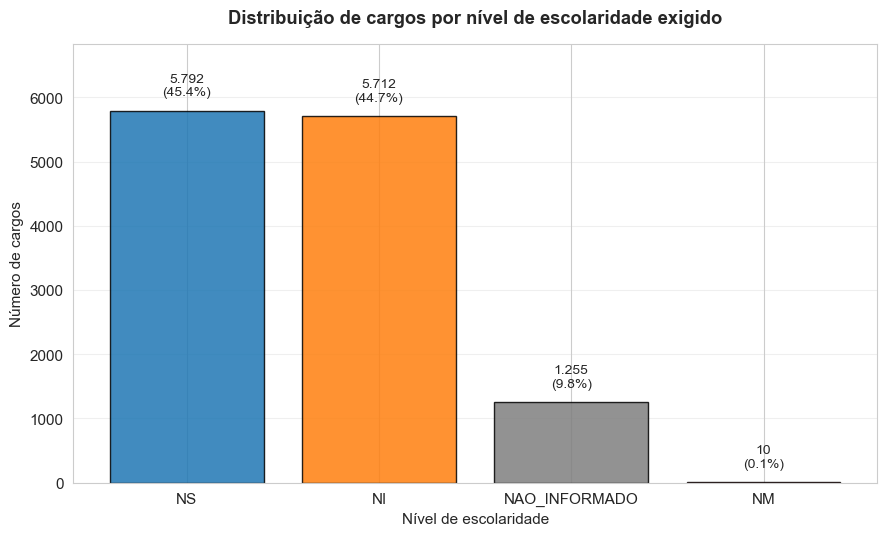

In [13]:
freq_nivel = df['nivel'].value_counts()

fig, ax = plt.subplots(figsize=(9, 5.5))
cores = [COR_PRIMARIA, COR_SECUNDARIA, COR_NEUTRA, COR_ALERTA]
bars = ax.bar(freq_nivel.index.astype(str), freq_nivel.values,
              color=cores[:len(freq_nivel)], edgecolor='black', alpha=0.85)
ax.set_ylabel('Número de cargos')
ax.set_xlabel('Nível de escolaridade')
ax.set_title('Distribuição de cargos por nível de escolaridade exigido',
             fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, axis='y')

# Aumentar limite superior para acomodar os rótulos
ax.set_ylim(0, freq_nivel.max() * 1.18)

# Rótulos com valor e percentual
total = freq_nivel.sum()
for bar, valor in zip(bars, freq_nivel.values):
    pct = valor / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total * 0.015,
            f'{valor:,}\n({pct:.1f}%)'.replace(',', '.'),
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(EVIDENCIAS / '06_distribuicao_nivel.png')
plt.show()

**O que este gráfico mostra:**

O Executivo Federal tem distribuição praticamente equilibrada entre cargos de Nível Superior (45,4%) e Nível Intermediário (44,7%). Cargos de Nível Médio são raríssimos (apenas 10 ocorrências), e cerca de 10% dos cargos não têm o nível informado na fonte — situação que decidimos preservar como categoria `NAO_INFORMADO` no Notebook 02.

### 4.3 Comparação dos tipos de vacância

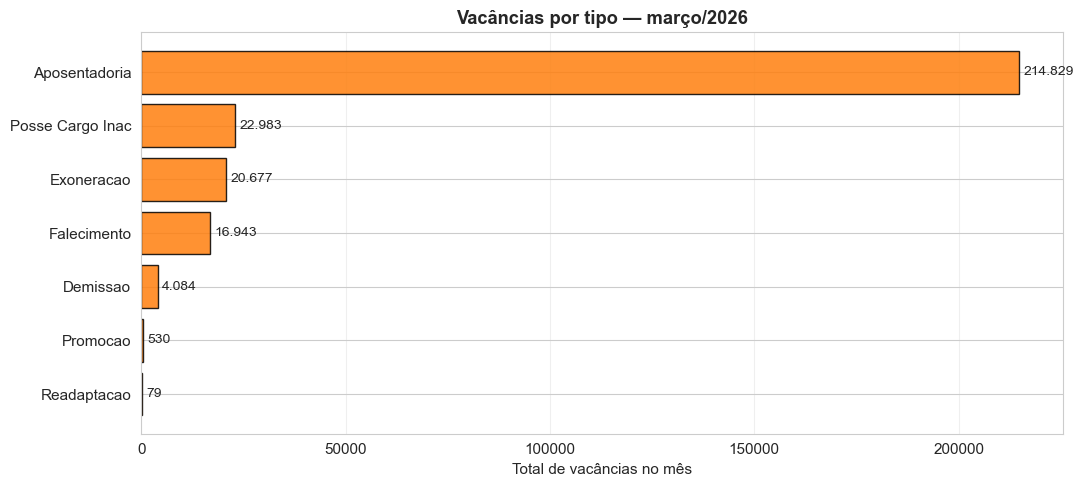

In [14]:
totais_vac = df[cols_vacancia].sum().sort_values(ascending=True)
labels_curtos = [c.replace('vac_', '').replace('_', ' ').title() for c in totais_vac.index]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(labels_curtos, totais_vac.values,
               color=COR_SECUNDARIA, edgecolor='black', alpha=0.85)
ax.set_xlabel('Total de vacâncias no mês')
ax.set_title('Vacâncias por tipo — março/2026', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Rótulos
for bar, valor in zip(bars, totais_vac.values):
    ax.text(bar.get_width() + max(totais_vac.values) * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{valor:,}'.replace(',', '.'),
            va='center', fontsize=10)

plt.tight_layout()
plt.savefig(EVIDENCIAS / '07_vacancias_por_tipo.png')
plt.show()

**O que este gráfico mostra:**

A **aposentadoria** é, com larguíssima margem, a principal causa de vacância no Executivo Federal — gerando aproximadamente **214.829 vacâncias**, valor muito superior a todos os outros motivos somados.

A ordem completa por volume:

1. **Aposentadoria** — 214.829 (≈ 75% do total)
2. **Posse em outro cargo inacumulável** — 22.983
3. **Exoneração** — 20.677
4. **Falecimento** — 16.943
5. **Demissão** — 4.084
6. **Promoção** — 530
7. **Readaptação** — 79

As duas últimas categorias (promoção e readaptação) são marginais — confirmando o que vimos no mapa de correlação (não escalam com o tamanho do cargo).

**Observação técnica:** os valores podem representar contagens acumuladas (e não apenas do mês de março/2026). O dicionário oficial não esclarece se a coluna registra eventos do mês ou histórico do cargo. Documentar essa incerteza é parte do tratamento responsável de dados públicos.

## 5. Identificação de relações entre variáveis

### 5.1 Mapa de calor de correlação

Mostra a correlação de Pearson entre as variáveis numéricas. Valores próximos de 1 indicam correlação positiva forte; próximos de -1, correlação negativa forte; próximos de 0, ausência de relação linear.

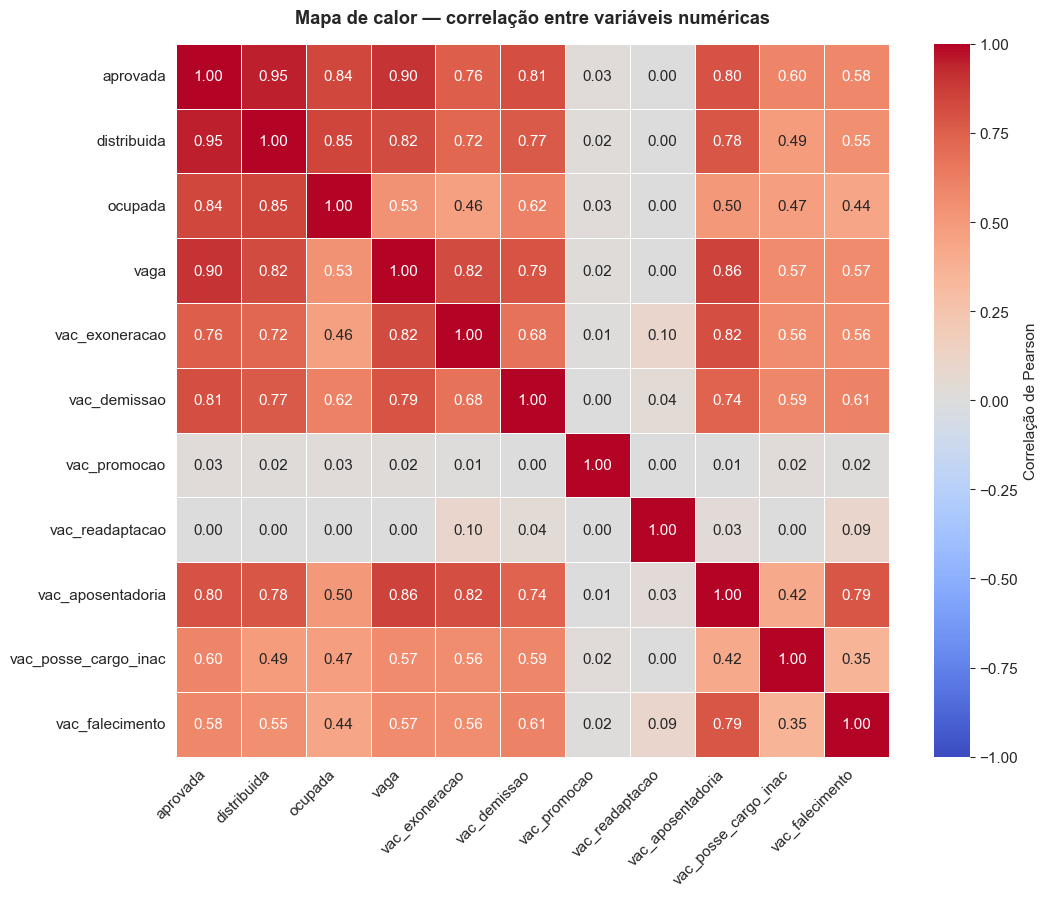

In [15]:
# Selecionar todas as variáveis numéricas (exceto a flag de outlier)
cols_correlacao = cols_principais + cols_vacancia
corr = df[cols_correlacao].corr()

# Labels mais curtos para legibilidade
labels_curtos = [c.replace('vac_', 'vac_').replace('qtd_', '') for c in corr.columns]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            xticklabels=labels_curtos,
            yticklabels=labels_curtos,
            cbar_kws={'label': 'Correlação de Pearson'},
            ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Mapa de calor — correlação entre variáveis numéricas',
             fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(EVIDENCIAS / '08_mapa_calor_correlacao.png')
plt.show()

**O que este gráfico mostra:**

**Correlações fortes (próximas de 1) — esperadas:**
- `aprovada`, `distribuida` e `ocupada` apresentam correlação próxima de **0.95** entre si. Isso é estrutural: cargos com muitas vagas aprovadas tendem a ter muitas distribuídas e ocupadas.
- `vac_aposentadoria`, `vac_exoneracao` e `vac_demissao` correlacionam-se entre si e com as variáveis principais (todas acima de 0.60) — isso é um **efeito de escala**: cargos grandes naturalmente geram mais movimentações em valor absoluto.

**Correlações fracas — também informativas:**
- `vac_promocao` e `vac_readaptacao` apresentam correlações próximas de **zero com praticamente tudo**. Isso indica que esses dois tipos de vacância **não escalam com o tamanho do cargo** — são fenômenos administrativos pontuais e raros, governados por regras próprias (mudança de classe na carreira, readaptação por restrição médica).

**Implicação prática:** as três variáveis (`qtd_aprovada`, `qtd_distribuida`, `qtd_ocupada`) carregam informação redundante. Em modelos preditivos, manter as três pode causar multicolinearidade. Esse insight orientará escolhas no Notebook 03 sobre derivação de features (como criar `taxa_ocupacao` ao invés de usar as três cruamente).

### 5.2 Boxplot comparativo — qtd_aprovada por nível de escolaridade

Mostra se cargos de diferentes níveis têm tamanhos típicos diferentes.

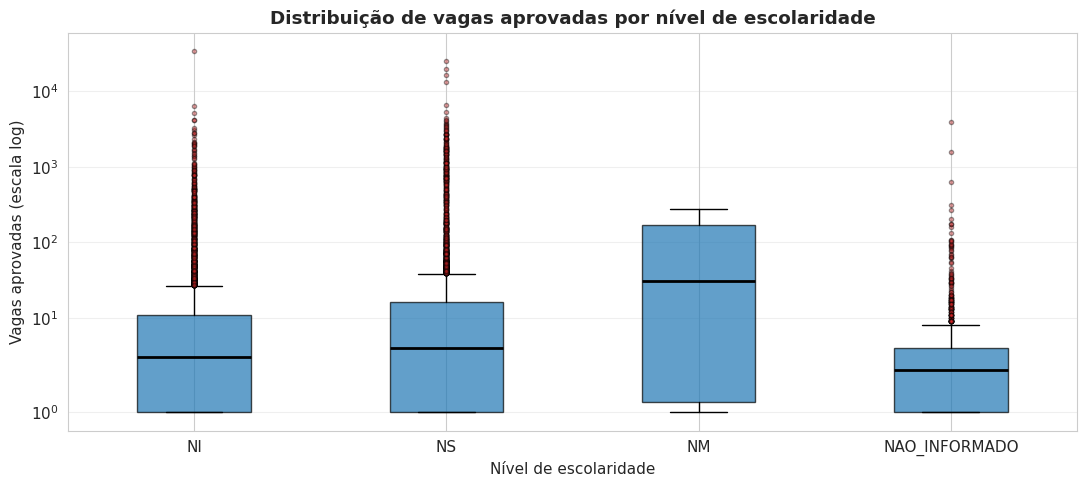

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
niveis_ordem = ['NI', 'NS', 'NM', 'NAO_INFORMADO']
dados_por_nivel = [df[df['nivel'] == n]['qtd_aprovada'] for n in niveis_ordem]

bp = ax.boxplot(dados_por_nivel, tick_labels=niveis_ordem, patch_artist=True,
                boxprops=dict(facecolor=COR_PRIMARIA, alpha=0.7),
                medianprops=dict(color='black', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor=COR_ALERTA,
                                markersize=3, alpha=0.4))
ax.set_yscale('symlog')
ax.set_xlabel('Nível de escolaridade')
ax.set_ylabel('Vagas aprovadas (escala log)')
ax.set_title('Distribuição de vagas aprovadas por nível de escolaridade',
             fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(EVIDENCIAS / '09_boxplot_aprovada_por_nivel.png')
plt.show()

**O que este gráfico mostra:**

Comparando as medianas:

| Nível | Mediana | Média | Quantidade |
|---|---|---|---|
| NM (Médio) | **30,5** | 83,9 | 10 |
| NS (Superior) | 4,0 | 75,7 | 5.792 |
| NI (Intermediário) | 3,0 | 43,4 | 5.712 |
| NAO_INFORMADO | 2,0 | 10,8 | 1.255 |

- **NM (Nível Médio)** tem a mediana visivelmente maior — mas com apenas **10 ocorrências**, é uma categoria pouco representativa estatisticamente. Não se deve tirar conclusões fortes sobre esse grupo.
- **NS (Superior)** e **NI (Intermediário)** têm medianas próximas (4 e 3), mas a **média do NS é quase o dobro do NI** (75,7 vs 43,4) — isso indica que cargos de Nível Superior têm mais outliers grandes (carreiras universitárias, médicas, jurídicas).
- **NAO_INFORMADO** apresenta a menor mediana (2) e a menor média (10,8), o que sugere que cargos com nível não informado tendem a ser **cargos menores em estrutura** — possivelmente cargos legados, em extinção ou de gestão administrativa pontual.

## 6. Análise de valores extremos (outliers)

Conforme identificado no Notebook 02, **1.879 registros (14,7%)** foram marcados como outliers em `qtd_aprovada` pelo método IQR. Vamos investigar quem são esses cargos.

In [16]:
# Os 10 maiores outliers
print("=== 10 maiores cargos (outliers) por vagas aprovadas ===\n")
top_outliers = df[df['is_outlier'] == 1].nlargest(10, 'qtd_aprovada')[
    ['sigla_orgao', 'nome_cargo', 'nivel', 'qtd_aprovada', 'qtd_ocupada', 'qtd_vaga']
]
top_outliers

=== 10 maiores cargos (outliers) por vagas aprovadas ===



,sigla_orgao,nome_cargo,nivel,qtd_aprovada,qtd_ocupada,qtd_vaga
12505,INSS,TECNICO DO SEGURO SOCIAL,NI,34209,13302,20907
1624,MS,MEDICO,NS,25473,2562,22911
718,MF,AUDITOR-FISCAL DA RECEITA FEDERAL BRASIL,NS,19642,6937,12705
719,MF,ANALISTA TRIBUTARIO REC FEDERAL BRASIL,NS,16341,6293,10048
10477,DPRF,POLICIAL RODOVIARIO FEDERAL,NS,13097,12840,257
12504,INSS,ANALISTA DO SEGURO SOCIAL,NS,6574,3969,2605
12073,IBGE,TEC INFOR GEOGRAFICAS E ESTATISTICA,NI,6284,2236,4048
1061,DPF,AGENTE DE POL FEDERAL CLASSE ESPECIAL,NS,5315,4103,1212
1459,MS,AUXILIAR DE ENFERMAGEM,NI,5206,4517,689
3777,UFRJ,PROFESSOR DO MAGISTERIO SUPERIOR,NS,4376,4013,363


In [17]:
# Distribuição dos outliers por nível
print("=== Outliers por nível de escolaridade ===")
print(df[df['is_outlier'] == 1]['nivel'].value_counts())

print("\n=== Outliers por status de extinção ===")
print(df[df['is_outlier'] == 1]['em_extincao'].value_counts())

=== Outliers por nível de escolaridade ===
nivel
NS               966
NI               861
NAO_INFORMADO     47
NM                 5
Name: count, dtype: int64

=== Outliers por status de extinção ===
em_extincao
N    1708
S     171
Name: count, dtype: int64


**O que esta análise mostra:**

Os outliers correspondem a **grandes carreiras institucionais reais e legítimas** do Executivo Federal:

- **Carreiras universitárias** (Professor do Magistério Superior, Técnico Administrativo em Educação) — naturalmente concentram milhares de servidores nas universidades federais.
- **Carreiras tributárias** (Auditor da Receita Federal, Analista Tributário) — grandes em razão do escopo nacional da arrecadação.
- **Carreiras de segurança e fiscalização** (Polícia Federal, Polícia Rodoviária Federal).

Esses cargos **não devem ser removidos** da análise — pelo contrário, são justamente os mais relevantes do ponto de vista de gestão pública. A decisão tomada no Notebook 02 de marcá-los com a flag `is_outlier` (em vez de removê-los) permite análises segmentadas quando necessário.

## 7. Análise temporal

O enunciado pede análise temporal **quando a base possuir datas**. Vamos verificar.

In [18]:
print(f"Valores únicos de ano_mes: {df['ano_mes'].unique()}")
print(f"Total de períodos: {df['ano_mes'].nunique()}")

Valores únicos de ano_mes: <DatetimeArray>
['2026-03-01 00:00:00']
Length: 1, dtype: datetime64[us]
Total de períodos: 1


**Conclusão da análise temporal:**

A base utilizada é um **snapshot mensal único** — competência março/2026 (`2026-03-01`). Não há múltiplos períodos para realizar análise temporal (séries históricas, sazonalidade, tendências).

A análise temporal poderia ser feita combinando esta base com bases de meses anteriores (publicadas mensalmente pelo SEGRT), o que está fora do escopo deste projeto mas é uma extensão natural sugerida na seção de "próximos passos" do relatório final.

## 8. Síntese dos padrões identificados

Consolidação dos achados desta análise exploratória:

### Padrões estruturais

1. **Distribuições altamente assimétricas** — todas as variáveis quantitativas exibem cauda longa à direita, com poucos cargos institucionais grandes dominando os valores totais.

2. **Aposentadoria é a principal forma de vacância** — em ordem de magnitude superior aos demais motivos somados. Implicação: gestão de pessoal pública precisa modelar pirâmide etária e tempo de contribuição como insumos primários.

3. **Forte correlação entre `aprovada`, `distribuida` e `ocupada`** — essas três variáveis carregam informação redundante. Indica oportunidade de criar variáveis derivadas mais informativas (taxas, percentuais).

4. **Cargos de Nível Superior (NS) têm média de tamanho maior que os de Nível Intermediário (NI)** — 75,7 contra 43,4 — refletindo a presença de grandes carreiras universitárias e técnicas. Cargos de Nível Médio (NM) são raros (10 ocorrências) e não permitem generalização estatística confiável.

5. **28% dos cargos estão em extinção** — sinal claro de reorganização administrativa contínua. Esses cargos precisam ser tratados de forma diferenciada em análises futuras.

### Implicações para os próximos notebooks

- **Notebook 03 (Feature Engineering):** criar `taxa_ocupacao`, `taxa_vagas` e `total_vacancias` como variáveis derivadas mais informativas que as cruas. Decompor `cod_cargo` em plano de carreira e cargo interno (estrutura 3+3 dígitos confirmada pelo dicionário).
- **Normalização:** dada a assimetria forte, métodos baseados em IQR (`RobustScaler`) tendem a ser mais adequados que `MinMaxScaler` ou `StandardScaler` puros.
- **Discretização:** as caudas longas justificam o uso de quantis (EFD - *equal frequency discretization*) em vez de intervalos iguais (EWD) para variáveis como `qtd_aprovada`.

---
*Fim do Notebook 02b — Análise Exploratória de Dados*